# Lab 4 — Wstęp do TensorFlow i klasyfikacja obrazów z użyciem CNN

**Wybrane Zagadnienia Sztucznej Inteligencji · II stopień**

---

## Co zrobimy na tym labie

1. **TensorFlow** — co to jest, dlaczego go używamy (zamiast pisać wszystko od zera jak na Lab 3)
2. **Tensory** — skalar, wektor, macierz, tensor ND
3. **MLP w TensorFlow** — ten sam pomysł co Lab 3, ale framework robi backpropagation za nas
4. **CNN** — konwolucyjne sieci neuronowe (sieci które *rozumieją* obrazy)
5. **Konwolucja, stride, padding, pooling, flatten** — cegiełki CNN
6. **Funkcje aktywacyjne** — ReLU, LeakyReLU, GeLU, softmax
7. **ZADANIE GŁÓWNE**: CNN klasyfikująca cyfry MNIST (architektura z instrukcji)
8. **Zadania dodatkowe** — optymalizatory, regularyzacja, augmentacja

> Dla początkujących: zerknij na `przygotowanie_dla_poczatkujacych.md` przed startem.

---

## Connect do Lab 3

Na Lab 3 budowaliśmy MLP **od zera** w numpy — sami pisaliśmy forward pass, sami liczyliśmy gradienty, sami aktualizowaliśmy wagi.

**Dzisiaj:** ten sam pomysł, ale **TensorFlow** robi wszystko za nas. Naszą pracą jest zaprojektowanie architektury — reszta dzieje się "pod maską".

---

## Mini-wprowadzenie dla początkujących

> Ta sekcja istnieje, żebyś **nie musiał wychodzić z notebooka** do `przygotowanie_dla_poczatkujacych.md`. Jeśli wszystko poniżej jest oczywiste — przeskocz. Jeśli pierwszy raz widzisz TensorFlow, przeczytaj 3 minuty.

### 1. Co tutaj w ogóle robimy?

Uczymy komputer **rozpoznawać cyfry na obrazkach** (0–9). Zamiast pisać sieć neuronową od zera w numpy (Lab 3), używamy frameworka **TensorFlow** — on robi za nas backpropagation, aktualizację wag, liczenie gradientów. Naszą pracą jest **zaprojektowanie architektury** (jakie warstwy, ile neuronów).

### 2. Cztery cegiełki CNN — tabelka do zapamiętania

| Cegiełka | Co robi | Analogia |
|----------|---------|----------|
| **Conv2D** | Przesuwa mały filtr po obrazie i wyciąga cechy (krawędzie, tekstury) | Patrzysz przez okienko 3×3 piksele i notujesz, co tam jest |
| **MaxPool2D** | Zmniejsza obraz 2×, biorąc maksimum z każdego regionu 2×2 | Streszczasz akapit — bierzesz najważniejsze słowo |
| **Flatten** | Zamienia 2D wynik na 1D wektor | Składasz kartkę papieru w linię |
| **Dense** | Zwykła warstwa neuronów (jak w MLP) | Klasyczna sieć — bierze cechy i decyduje "to cyfra 7" |

**Cała CNN** = Conv2D → Pool → Conv2D → Pool → Flatten → Dense → Output.

### 3. Tensor — co to znaczy?

Tensor to po prostu **wielowymiarowa tabelka liczb**. Skalar (0D) = jedna liczba. Wektor (1D) = lista. Macierz (2D) = tabela. Tensor 3D = sześcian (np. obraz RGB). Tensor 4D = batch obrazów. Nic magicznego.

### 4. Słownik EN → PL (najważniejsze)

| EN | PL | Znaczenie |
|----|-----|-----------|
| layer | warstwa | jeden poziom sieci |
| filter / kernel | filtr / jądro | mała macierz do konwolucji |
| feature map | mapa cech | wynik konwolucji |
| epoch | epoka | jedno przejście przez cały zbiór treningowy |
| batch | partia | grupka próbek aktualizująca wagi naraz |
| loss | strata | jak bardzo sieć się myli (niżej = lepiej) |
| accuracy | dokładność | % poprawnych predykcji (wyżej = lepiej) |
| overfitting | przeuczenie | sieć zna trening na pamięć, ale fails na teście |

### 5. Jak czytać krzywe treningu (zapowiedź)

Każdy wykres treningu pokaże dwie linie:
- **train** — wynik na danych z których sieć się uczy.
- **validation** — wynik na danych których sieć **nie widziała** przy aktualizacji wag.

Idą razem w górę → dobrze. Train rośnie a validation stoi/spada → **overfitting**.

> **Jeśli zgubisz się gdziekolwiek dalej — wróć tutaj.**


---

## 0. Setup

Instalacja (jeśli nie masz):

```bash
pip install tensorflow
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU dostepne:        {len(tf.config.list_physical_devices('GPU')) > 0}")
print()
print("Tip: trening CNN na CPU dziala, ale na GPU jest ~10x szybszy.")

TensorFlow version: 2.21.0
GPU dostepne:        False

Tip: trening CNN na CPU dziala, ale na GPU jest ~10x szybszy.


---

## 1. Tensory — fundament TensorFlow

**Tensor** to ogólne pojęcie — matematyczne uogólnienie skalarów, wektorów i macierzy.

| Wymiar | Nazwa | Przykład | Zastosowanie |
|--------|-------|----------|--------------|
| 0D | Skalar | `5` | Pojedyncza liczba (np. learning rate) |
| 1D | Wektor | `[1, 2, 3]` | Cechy jednej próbki |
| 2D | Macierz | `[[1,2],[3,4]]` | Batch wektorów lub obraz w skali szarości |
| 3D | Tensor | `[[[...]]]` | Obraz RGB (height x width x channels) |
| 4D | Tensor | `[[[[...]]]]` | Batch obrazów (batch x h x w x c) |

TensorFlow operuje na tensorach — stąd nazwa.

In [2]:
# Skalar (0D)
skalar = tf.constant(5.0)
print(f"Skalar:  {skalar.numpy()},  shape: {skalar.shape}")

# Wektor (1D)
wektor = tf.constant([1.0, 2.0, 3.0])
print(f"Wektor:  {wektor.numpy()},  shape: {wektor.shape}")

# Macierz (2D)
macierz = tf.constant([[1.0, 2.0], [3.0, 4.0]])
print(f"Macierz:\n{macierz.numpy()}\nshape: {macierz.shape}")

# Tensor 3D (np. obraz RGB 2x2x3)
tensor3d = tf.random.uniform((2, 2, 3))
print(f"\nTensor 3D shape: {tensor3d.shape}  (np. maly obraz RGB)")

# Tensor 4D (batch obrazow 28x28 grayscale, batch=4)
tensor4d = tf.random.uniform((4, 28, 28, 1))
print(f"Tensor 4D shape: {tensor4d.shape}  (batch 4 obrazow 28x28x1)")

Skalar:  5.0,  shape: ()
Wektor:  [1. 2. 3.],  shape: (3,)
Macierz:
[[1. 2.]
 [3. 4.]]
shape: (2, 2)

Tensor 3D shape: (2, 2, 3)  (np. maly obraz RGB)
Tensor 4D shape: (4, 28, 28, 1)  (batch 4 obrazow 28x28x1)


### Co właśnie zobaczyliśmy?

Każdy print pokazał **wartość tensora** i jego **`shape`** (kształt). Czytaj to tak:

- `shape: ()` — pusty nawias = **brak wymiarów** → to jedna liczba (skalar).
- `shape: (3,)` — jedna liczba z przecinkiem = **wektor 1D** o 3 elementach.
- `shape: (2, 2)` — dwie liczby = **macierz 2D**: 2 wiersze × 2 kolumny.
- `shape: (2, 2, 3)` — trzy liczby = **tensor 3D**: wyobraź sobie 2 obrazki 2×2 piksele × 3 kanały koloru (RGB).
- `shape: (4, 28, 28, 1)` — cztery liczby = **tensor 4D**: batch 4 obrazków, każdy 28×28 pikseli, 1 kanał (grayscale).

**Reguła do zapamiętania:** pierwszy wymiar to zawsze **batch** (paczka próbek), a kolejne opisują pojedynczą próbkę. Cała CNN będzie operować na tensorach 4D `(batch, height, width, channels)`.


---

## 2. MLP w TensorFlow — to samo co Lab 3, ale 5x mniej kodu

Na Lab 3 pisaliśmy ~50 linii numpy, żeby zbudować MLP. W TensorFlow to **3 linie**.

### Architektura przykładowa: MLP na MNIST
- Wejście: 784 piksele (spłaszczony obraz 28x28)
- Warstwa ukryta 1: 128 neuronów, ReLU
- Warstwa ukryta 2: 64 neurony, ReLU
- Wyjście: 10 neuronów (10 klas cyfr), softmax

x_train shape: (60000, 28, 28)  (60000 obrazow 28x28)
y_train shape: (60000,)  (60000 etykiet)
Zakres pikseli: [0, 255]
Klasy: [0 1 2 3 4 5 6 7 8 9]


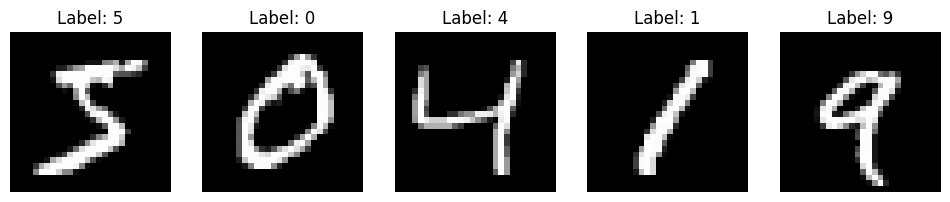

In [3]:
# Krok 1: Wczytanie MNIST (TensorFlow ma to wbudowane!)
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"x_train shape: {x_train.shape}  (60000 obrazow 28x28)")
print(f"y_train shape: {y_train.shape}  (60000 etykiet)")
print(f"Zakres pikseli: [{x_train.min()}, {x_train.max()}]")
print(f"Klasy: {np.unique(y_train)}")

# Podglad kilku obrazow
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.show()

### Co widzisz na obrazku?

Pięć czarno-białych kwadratów to **prawdziwe rękopisy cyfr** z bazy MNIST (zbiór zebrany od pracowników US Census i licealistów w latach 90.). Każdy obrazek to:

- **28 × 28 pikseli** (mały — zmieściłbyś się 10 takich obok siebie na ekranie).
- **Skala szarości** — każdy piksel to liczba od 0 (czarny) do 255 (biały).
- Nad każdym tytuł "Label: X" — **prawdziwa odpowiedź** (etykieta), znana nam, ale **nie pokazywana sieci** w trakcie predykcji.

**Co widzi sieć?** Nie cyfrę. Widzi **784 liczb** ułożonych w siatkę. Naszym celem jest tak dobrać wagi, żeby z tych 784 liczb sieć potrafiła wyprowadzić odpowiedź "to jest 5".

Mamy **60 000** takich obrazków na trening i **10 000** na test — solidna baza jak na klasyczny dataset edukacyjny.


In [4]:
# Krok 2: Przygotowanie danych dla MLP
# - reshape: (28, 28) -> (784,) bo MLP przyjmuje wektor
# - normalizacja: /255.0 zeby wartosci byly w [0, 1]
# - one-hot encoding etykiet: 3 -> [0,0,0,1,0,0,0,0,0,0]

x_train_mlp = x_train.reshape(-1, 28 * 28) / 255.0
x_test_mlp = x_test.reshape(-1, 28 * 28) / 255.0

y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_test_oh = tf.keras.utils.to_categorical(y_test, 10)

print(f"x_train_mlp shape: {x_train_mlp.shape}  (60000 wektorow 784)")
print(f"y_train_oh shape:  {y_train_oh.shape}   (60000 wektorow one-hot)")
print(f"Przyklad one-hot dla etykiety {y_train[0]}: {y_train_oh[0]}")

x_train_mlp shape: (60000, 784)  (60000 wektorow 784)
y_train_oh shape:  (60000, 10)   (60000 wektorow one-hot)
Przyklad one-hot dla etykiety 5: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [5]:
# Krok 3: Budowa modelu MLP (tu jest cala "magia" -- 3 linie!)
model_mlp = tf.keras.models.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(28 * 28,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_mlp.summary()

/opt/miniconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### Jak czytać `model.summary()`?

Wydruk to tabela z **3 kolumnami**:

| Kolumna | Co znaczy |
|---------|-----------|
| **Layer (type)** | Nazwa warstwy i jej typ (Dense, Conv2D, …) |
| **Output Shape** | Kształt tensora, który wychodzi z tej warstwy |
| **Param #** | Liczba **wag do nauczenia** w tej warstwie |

**Co tu siedzi (dla naszej MLP):**

- `Dense(128)`: wejście 784 → wyjście 128. Parametry = `784 × 128 + 128` (biasy) = **100 480**.
- `Dense(64)`: `128 × 64 + 64` = **8 256**.
- `Dense(10)`: `64 × 10 + 10` = **650**.
- **Razem ~109 386 parametrów** — wszystkie zostaną "podkręcone" w trakcie treningu.

**"(None, 128)" w Output Shape** — `None` oznacza "dowolnie duży batch". Druga liczba (128) to faktyczna liczba cech na próbkę.

Dla porównania: na Lab 3 sieć 2-2-1 miała ~9 wag. Tutaj **~100 tysięcy**. Framework liczy to za nas — i właśnie dlatego używamy TensorFlow.


In [6]:
# Krok 4: Kompilacja modelu
# - optimizer: jak aktualizujemy wagi (Adam = ulepszony SGD)
# - loss: jak mierzymy blad (categorical_crossentropy dla klasyfikacji wieloklasowej)
# - metrics: co mierzymy podczas treningu (accuracy = % poprawnych predykcji)
model_mlp.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Krok 5: Trening!
# - epochs=5: przejdziemy 5 razy przez caly zbior
# - batch_size=32: aktualizujemy wagi po kazdej paczce 32 probek
# - validation_split=0.2: 20% danych treningowych uzywamy do walidacji (sprawdzania)
history_mlp = model_mlp.fit(
    x_train_mlp, y_train_oh,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5


   1/1500 ━━━━━━━━━━━━━━━━━━━━ 10:11 408ms/step - accuracy: 0.1250 - loss: 2.2472

  59/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 867us/step - accuracy: 0.4414 - loss: 1.7209   

 122/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - accuracy: 0.5762 - loss: 1.3463

 180/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 843us/step - accuracy: 0.6399 - loss: 1.1570

...

1300/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 893us/step - accuracy: 0.9855 - loss: 0.0449

1357/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 893us/step - accuracy: 0.9855 - loss: 0.0449

1414/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 892us/step - accuracy: 0.9855 - loss: 0.0450

1471/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 892us/step - accuracy: 0.9854 - loss: 0.0450

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9848 - loss: 0.0467 - val_accuracy: 0.9697 - val_loss: 0.1037


In [7]:
# Krok 6: Ewaluacja na zbiorze testowym (modelem nie widzial tych danych!)
test_loss, test_accuracy = model_mlp.evaluate(x_test_mlp, y_test_oh, verbose=0)
print(f"Test accuracy: {test_accuracy:.4f}  (~{test_accuracy*100:.1f}%)")
print(f"Test loss:     {test_loss:.4f}")

# Krok 7: Predykcja na konkretnych przykladach
predictions = model_mlp.predict(x_test_mlp[:5], verbose=0)
print(f"\nPredykcje (argmax): {predictions.argmax(axis=1)}")
print(f"Prawdziwe etykiety: {y_test[:5]}")

Test accuracy: 0.9721  (~97.2%)
Test loss:     0.0960

Predykcje (argmax): [7 2 1 0 4]
Prawdziwe etykiety: [7 2 1 0 4]


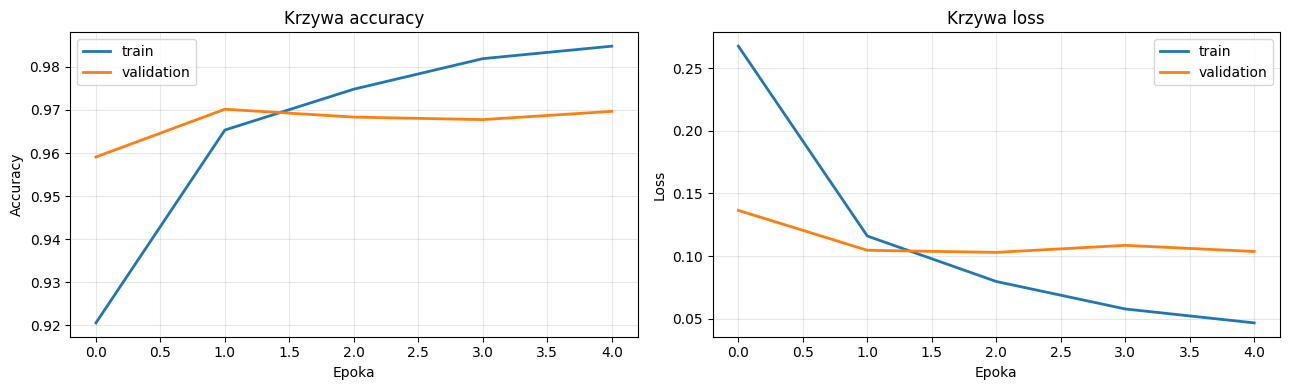

In [8]:
# Wykres treningu -- accuracy i loss
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_mlp.history['accuracy'], label='train', linewidth=2)
axes[0].plot(history_mlp.history['val_accuracy'], label='validation', linewidth=2)
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Krzywa accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_mlp.history['loss'], label='train', linewidth=2)
axes[1].plot(history_mlp.history['val_loss'], label='validation', linewidth=2)
axes[1].set_xlabel('Epoka')
axes[1].set_ylabel('Loss')
axes[1].set_title('Krzywa loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Jak czytać krzywe treningu? (kluczowy wykres!)

Dwa panele obok siebie:

| Panel | Oś Y | Im wyższe / niższe… |
|-------|------|----------------------|
| **Lewy — Accuracy** | dokładność (0–1) | **wyżej = lepiej** (1.0 = 100% trafień) |
| **Prawy — Loss** | strata (cross-entropy) | **niżej = lepiej** (0 = idealna predykcja) |

**Oś X (Epoka)** — każda epoka = sieć przeszła **raz** przez wszystkie 60 000 obrazków.

**Dwie linie na każdym wykresie:**
- **train** (niebieska) — wynik na danych z których sieć **aktywnie się uczy**.
- **validation** (pomarańczowa) — wynik na 20% danych odłożonych na bok (nie aktualizujemy na nich wag). To symuluje "świat rzeczywisty".

**Jak interpretować różne scenariusze:**

| Co widzisz | Co to znaczy |
|------------|--------------|
| Obie linie rosną razem (accuracy) | **Dobrze.** Sieć się uczy i generalizuje. |
| Train rośnie, val stoi lub spada | **Overfitting.** Sieć "zapamiętała" trening, ale nie umie wnioskować na nowych danych. |
| Obie linie utknęły na 10% accuracy | Coś nie działa (sprawdź normalizację, shape, etykiety). 10% = losowanie z 10 klas. |
| Loss spada szybko w 1–2 epoce, potem płasko | Sieć szybko nauczyła się "łatwych" wzorców — dalej dopieszcza. Normalne. |

Dla tego MLP typowo: **~97–98% accuracy** na MNIST. Solidnie, ale CNN później pokaże jeszcze więcej.


---

## 3. Co to jest CNN?

MLP **nie rozumie obrazów** — spłaszcza je w 784-elementowy wektor i traci informację o tym, które piksele są obok siebie. To działa dla MNIST (90–98%), ale na trudniejszych obrazach (np. CIFAR-10, ImageNet) jest słaby.

**CNN (Convolutional Neural Network)** to sieć, która:
- Zachowuje informację o **sąsiedztwie pikseli**
- Automatycznie wykrywa **lokalne wzorce** (krawędzie, tekstury, kształty)
- Używa **tych samych wag** w wielu miejscach obrazu (parameter sharing)

### Trzy kluczowe idee konwolucji

1. **Rzadkie interakcje** (sparse interactions) — neuron patrzy tylko na mały region, nie cały obraz
2. **Dzielenie parametrów** (parameter sharing) — ten sam filtr przesuwamy po całym obrazie
3. **Reprezentacja ekwiwariantna** — jeśli krawędź przesunie się w obrazie, jej reprezentacja też się przesunie

---

## 4. Konwolucja — jak działa kernel

**Konwolucja** = przesuwanie małej macierzy (**kernel/filter**) po wejściu i obliczanie sumy iloczynów.

```
Input 3x3:        Kernel 2x2:       Output 2x2:
[[0, 1, 2],       [[0, 1],          [[19, 25],
 [3, 4, 5],   *    [2, 3]]    =      [37, 43]]
 [6, 7, 8]]
```

Wzor: `19 = 0*0 + 1*1 + 3*2 + 4*3 = 0 + 1 + 6 + 12 = 19`

Kernel przesuwa się po obrazie, w każdej pozycji robi mnożenie+sumowanie — dostajemy **feature map**.

In [9]:
# Demo konwolucji recznie
input_matrix = np.array([
    [0, 1, 2],
    [3, 4, 5],
    [6, 7, 8]
])
kernel = np.array([
    [0, 1],
    [2, 3]
])

# Reczna konwolucja
h, w = input_matrix.shape
kh, kw = kernel.shape
out_h, out_w = h - kh + 1, w - kw + 1
output = np.zeros((out_h, out_w))

for i in range(out_h):
    for j in range(out_w):
        region = input_matrix[i:i+kh, j:j+kw]
        output[i, j] = np.sum(region * kernel)

print("Input:")
print(input_matrix)
print("\nKernel:")
print(kernel)
print("\nOutput (po konwolucji):")
print(output.astype(int))
print("\nKazda liczba to suma iloczynow kernela z regionem inputu.")

Input:
[[0 1 2]
 [3 4 5]
 [6 7 8]]

Kernel:
[[0 1]
 [2 3]]

Output (po konwolucji):
[[19 25]
 [37 43]]

Kazda liczba to suma iloczynow kernela z regionem inputu.


### Co właśnie policzyliśmy?

To była **konwolucja krok po kroku** wykonana ręcznie (bez TensorFlow):

1. **Wejście:** macierz 3×3 z liczbami 0–8 (po prostu uporządkowane).
2. **Kernel:** macierz 2×2 z liczbami 0, 1, 2, 3.
3. Kernel **ślizga się** po wejściu — mieści się w **4 pozycjach**: lewy-góra, prawy-góra, lewy-dół, prawy-dół.
4. W każdej pozycji: **mnoży element-po-elemencie** wartości kernela z odpowiadającym fragmentem wejścia, potem **sumuje** wszystko → **jedna liczba** w wyjściu.

**Wzór dla lewego-górnego rogu:** `0·0 + 1·1 + 2·3 + 3·4 = 0 + 1 + 6 + 12 = 19` ✓

**Wynik 2×2** to **feature map** — mała mapka mówiąca "tutaj kernel mocno zareagował, a tutaj słabo".

**W prawdziwej CNN:** zamiast 4 pozycji mamy **setki** (na obrazie 28×28), zamiast 1 kernela mamy **dziesiątki** (np. 24 w pierwszej warstwie), wszystko liczone równolegle na GPU.


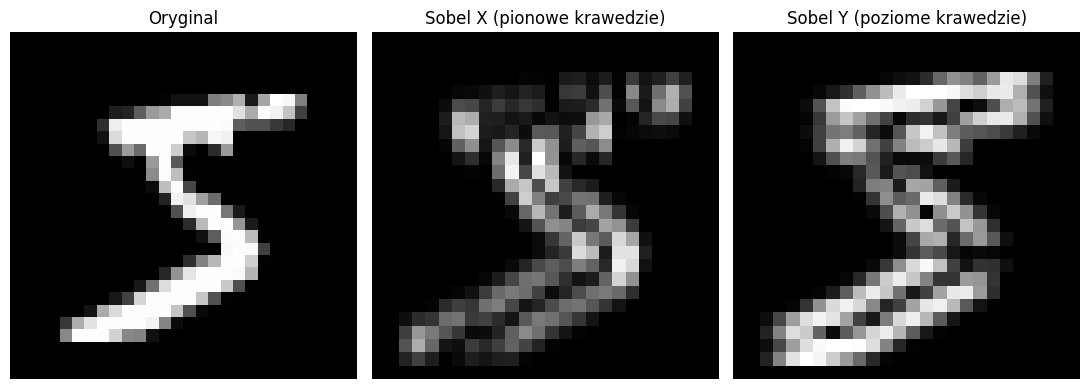

To wlasnie robi konwolucja: wyciaga konkretne cechy z obrazu.
CNN UCZY SIE jakich filtrow uzywac -- nie definiujesz ich recznie!


In [10]:
# Pokazmy efekt konwolucji na PRAWDZIWYM obrazie -- kernel "wykrywanie krawedzi"
from scipy.signal import convolve2d

obraz = x_train[0].astype(float)  # cyfra z MNIST

# Sobel filter -- wykrywa pionowe krawedzie
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

# Sobel filter -- wykrywa poziome krawedzie
sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

obraz_x = convolve2d(obraz, sobel_x, mode='valid')
obraz_y = convolve2d(obraz, sobel_y, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
axes[0].imshow(obraz, cmap='gray')
axes[0].set_title("Oryginal")
axes[0].axis('off')
axes[1].imshow(np.abs(obraz_x), cmap='gray')
axes[1].set_title("Sobel X (pionowe krawedzie)")
axes[1].axis('off')
axes[2].imshow(np.abs(obraz_y), cmap='gray')
axes[2].set_title("Sobel Y (poziome krawedzie)")
axes[2].axis('off')
plt.tight_layout()
plt.show()

print("To wlasnie robi konwolucja: wyciaga konkretne cechy z obrazu.")
print("CNN UCZY SIE jakich filtrow uzywac -- nie definiujesz ich recznie!")

### Co widzisz na trzech panelach?

| Panel | Co pokazuje |
|-------|-------------|
| **Lewy — "Oryginal"** | Surowa cyfra z MNIST w skali szarości |
| **Środkowy — "Sobel X"** | Ta sama cyfra po przejściu kernela wykrywającego **pionowe krawędzie** |
| **Prawy — "Sobel Y"** | Ta sama cyfra po przejściu kernela wykrywającego **poziome krawędzie** |

**Jak czytać Sobela:** jasne piksele = "tutaj jest krawędź", ciemne = "tutaj nic ciekawego". Na panelu środkowym świecą tylko pionowe linie cyfry, na prawym tylko poziome. Reszta obrazka zniknęła — bo filtr Sobela **jest zaprojektowany** by wykryć tylko jeden rodzaj informacji.

**NAJWAŻNIEJSZA MYŚL TEJ SEKCJI:**

> Filtr Sobela został wymyślony przez człowieka — wiemy że wykrywa krawędzie i sami zapisujemy w nim liczby. Ale w CNN **sieć sama uczy się** 24 filtrów w pierwszej warstwie. Niektóre wykryją krawędzie (jak Sobel), inne kropki, inne łuki — **co tylko jest potrzebne do rozróżnienia cyfr**. **My nie programujemy filtrów — sieć je sobie wymyśla podczas treningu.**

To jest serce deep learningu: zamiast ręcznie wymyślać "co wyciągnąć z obrazu", pozwalamy sieci samej zdecydować.


---

## 5. Stride i Padding

### Stride — jak szybko przesuwamy kernel
- `stride=1`: kernel przesuwa się o 1 piksel → analizujemy każdy region
- `stride=2`: kernel "przeskakuje" co drugi piksel → wynik 2x mniejszy

### Padding — dodajemy zera na krawędziach
Bez paddingu obraz po konwolucji **kurczy się** (28x28 z kernel 3x3 → 26x26). Padding dodaje ramkę zer wokół obrazu, żeby zachować rozmiar.

### Wzor na rozmiar wyjścia

$$\text{output} = \frac{\text{input} + 2 \cdot \text{padding} - \text{kernel}}{\text{stride}} + 1$$

Przykład: 28 wejście, kernel 3, stride 1, padding 0 → (28 - 3) / 1 + 1 = **26**

In [11]:
def output_size(input_size, kernel_size, padding=0, stride=1):
    return (input_size + 2 * padding - kernel_size) // stride + 1

print("Kalkulator rozmiaru wyjscia konwolucji:\n")
for params in [
    (28, 3, 0, 1),  # MNIST z kernel 3, bez paddingu
    (28, 3, 1, 1),  # MNIST z kernel 3, padding 1 (zachowuje rozmiar)
    (28, 3, 0, 2),  # stride 2 -- redukcja 2x
    (28, 5, 2, 1),  # kernel 5 z paddingiem 2 -- zachowuje rozmiar
]:
    inp, ker, pad, stride = params
    out = output_size(inp, ker, pad, stride)
    print(f"  input={inp}, kernel={ker}, padding={pad}, stride={stride}  =>  output={out}")

Kalkulator rozmiaru wyjscia konwolucji:

  input=28, kernel=3, padding=0, stride=1  =>  output=26
  input=28, kernel=3, padding=1, stride=1  =>  output=28
  input=28, kernel=3, padding=0, stride=2  =>  output=13
  input=28, kernel=5, padding=2, stride=1  =>  output=28


### Co tu się wydarzyło?

Każdy wiersz pokazuje **inną konfigurację konwolucji** i jej wynikowy rozmiar wyjścia:

| input | kernel | padding | stride | output | Komentarz |
|-------|--------|---------|--------|--------|-----------|
| 28 | 3 | 0 | 1 | **26** | Klasyka — obraz traci 2 piksele (po 1 z każdej strony) |
| 28 | 3 | 1 | 1 | **28** | Dodaliśmy ramkę zer wokół — rozmiar **zachowany** |
| 28 | 3 | 0 | 2 | **13** | Stride 2 = kernel przeskakuje co 2 piksele → wyjście ~2× mniejsze |
| 28 | 5 | 2 | 1 | **28** | Większy kernel + większy padding = zachowany rozmiar |

**Po co to liczyć?** Żeby zaplanować architekturę. Jeśli zrobisz 10 warstw bez paddingu, obraz "skurczy się do niczego" zanim dojdziesz do końca.

**W naszej CNN (zadanie główne) rozmiar zmienia się tak:**

```
28×28  → Conv2D(3×3)  →  26×26
       → MaxPool(2×2) →  13×13
       → Conv2D(3×3)  →  11×11
       → MaxPool(2×2) →   5×5
       → Flatten       →  900 (= 5·5·36)
```

Po tym wszystkim wpadamy w Dense(128) → Dense(10).


---

## 6. Pooling — zmniejszamy rozmiar, zachowujemy najważniejsze

Po konwolucji obraz nadal jest duży. **Pooling** dzieli go na małe regiony (np. 2x2) i zastępuje każdy region **jedną wartością**.

- **Max pooling** — wybiera maksymalną wartość (zachowuje najmocniejsze cechy)
- **Avg pooling** — średnia (zachowuje więcej szczegółów)

```
Input 4x4:           Max Pool 2x2:
[[2, 2, 7, 3],       [[9, 7],
 [9, 4, 6, 1],   ->   [8, 6]]
 [8, 5, 2, 4],
 [3, 1, 2, 6]]
```

Pooling **nie ma wag** — to czysta operacja matematyczna. Cele:
- Redukcja rozmiaru (mniej obliczeń)
- Zapobieganie overfittingowi

In [12]:
# Demo max poolingu recznie
input_4x4 = np.array([
    [2, 2, 7, 3],
    [9, 4, 6, 1],
    [8, 5, 2, 4],
    [3, 1, 2, 6]
])

def max_pool_2x2(x):
    h, w = x.shape
    out = np.zeros((h // 2, w // 2))
    for i in range(0, h, 2):
        for j in range(0, w, 2):
            out[i // 2, j // 2] = x[i:i+2, j:j+2].max()
    return out

print("Input 4x4:")
print(input_4x4)
print("\nMax Pool 2x2:")
print(max_pool_2x2(input_4x4).astype(int))

# W TensorFlow to jedna linijka
tf_input = tf.constant(input_4x4.reshape(1, 4, 4, 1), dtype=tf.float32)
tf_output = tf.nn.max_pool2d(tf_input, ksize=2, strides=2, padding='VALID')
print(f"\nTo samo w TensorFlow: tf.nn.max_pool2d(ksize=2, strides=2)")
print(tf_output.numpy().reshape(2, 2).astype(int))

Input 4x4:
[[2 2 7 3]
 [9 4 6 1]
 [8 5 2 4]
 [3 1 2 6]]

Max Pool 2x2:
[[9 7]
 [8 6]]

To samo w TensorFlow: tf.nn.max_pool2d(ksize=2, strides=2)
[[9 7]
 [8 6]]


### Co widzisz w wyniku?

**Wejście:** macierz 4×4 z 16 liczbami. **Wyjście:** macierz 2×2 (czyli **4× mniej liczb**).

Max pooling działa tak:
1. Dzielimy wejście na **kwadraty 2×2** (mamy 4 kwadraty).
2. Z każdego kwadratu bierzemy **maksimum**.

| Kwadrat | Wartości | Max |
|---------|----------|-----|
| Lewy-góra | 2, 2, 9, 4 | **9** |
| Prawy-góra | 7, 3, 6, 1 | **7** |
| Lewy-dół | 8, 5, 3, 1 | **8** |
| Prawy-dół | 2, 4, 2, 6 | **6** |

Wynik: `[[9, 7], [8, 6]]` — **tylko najmocniejsze sygnały** przeżyły.

**Dwie wartości tej operacji:**

1. **Redukcja:** 4× mniej liczb → szybsze obliczenia w kolejnych warstwach.
2. **Niezmienniczość na przesunięcia:** cyfra przesunięta o 1 piksel nadal aktywuje ten sam region 2×2 → max pooling daje ten sam wynik. Dla MLP przesunięcie o 1 piksel to **zupełnie inny wektor wejściowy** — może się wywalić.

Pooling **nie ma wag** — to czysta matematyka. Nie ma czego się uczyć.


---

## 7. Flatten — most między CNN a fully connected

Po wszystkich konwolucjach i poolingach mamy **tensor wielowymiarowy** (np. 5x5x36). Żeby przekazać go do warstwy `Dense` (klasyfikacja), musimy zamienić go w **wektor**.

**Flatten** = `reshape(-1)` — sppłaszczamy wszystko w 1D.

Przykład: tensor 5x5x36 → wektor 900 (= 5·5·36).

In [13]:
# Flatten w akcji
tensor_3d = np.array([
    [1, 2, 1],
    [4, 2, 1],
    [0, 2, 1]
])

print(f"Tensor 3x3:\n{tensor_3d}")
print(f"\nFlatten -> wektor 9: {tensor_3d.flatten()}")

# W TensorFlow uzywamy tf.keras.layers.Flatten()
# Wlasnie ta warstwa laczy konwolucyjna czesc z klasyfikacyjna

Tensor 3x3:
[[1 2 1]
 [4 2 1]
 [0 2 1]]

Flatten -> wektor 9: [1 2 1 4 2 1 0 2 1]


### Co właśnie się stało?

Mieliśmy tabelkę 3×3 = **9 liczb ułożonych w 2 wymiarach**. `flatten()` rozłożył je w **jedną linię** — czytając wiersz po wierszu od lewej do prawej.

```
[[1, 2, 1],            [1, 2, 1, 4, 2, 1, 0, 2, 1]
 [4, 2, 1],     →
 [0, 2, 1]]
```

**Dlaczego to potrzebne?** Warstwy `Dense` (klasyczne, jak w MLP) przyjmują **wektor 1D**, nie tabelę 2D/3D. Flatten to **tłumacz** między światem CNN (mapy cech 2D) a światem klasyfikacji (lista cech do podjęcia decyzji).

**W naszej architekturze:** po 2 konwolucjach i 2 poolingach mamy tensor `5×5×36` (5 piksele × 5 pikseli × 36 map cech). Flatten zamieni to w wektor **900** (= 5·5·36), który wejdzie do `Dense(128)`.

Flatten **nie ma wag** — to tylko zmiana kształtu (`reshape`).


---

## 8. Funkcje aktywacyjne w CNN

Na Lab 3 mieliśmy **sigmoid** i **tanh**. W CNN dominują inne:

| Funkcja | Wzór | Kiedy |
|---------|------|-------|
| **ReLU** | `max(0, x)` | Domyślna w warstwach ukrytych — szybka, brak vanishing gradient |
| **Leaky ReLU** | `x jeśli x>0, alpha*x w innym` | Gdy ReLU "umiera" (dużo neuronów zwraca 0) |
| **GeLU** | `x * Φ(x)` (CDF rozkładu normalnego) | Nowoczesne sieci (BERT, GPT) |
| **Softmax** | `e^x / sum(e^x)` | Warstwa wyjściowa klasyfikacji wieloklasowej |

ReLU = `max(0, x)` to **najpopularniejsza** funkcja aktywacji w deep learning. Dlaczego?
- Trywialna do obliczenia
- Pochodna jest 0 lub 1 — nie ma problemu "vanishing gradient" jak w sigmoid
- W praktyce świetnie działa

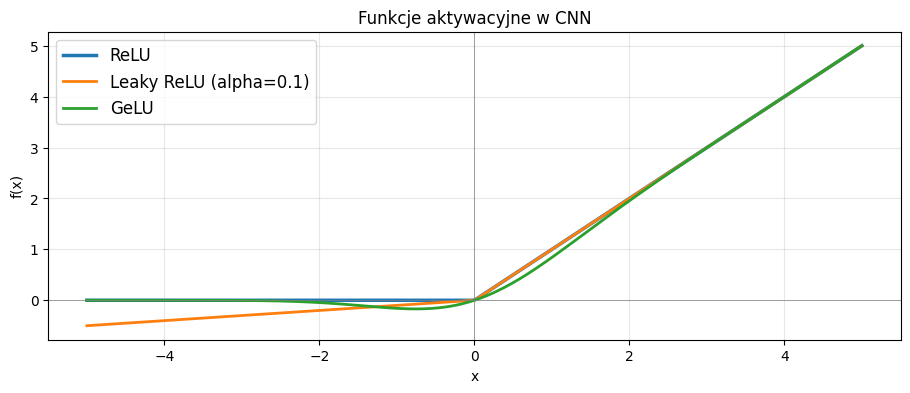

Roznice:
  ReLU: prosto, ale neurony moga 'umrzec' (utknac w zerze)
  Leaky ReLU: malo nachylenie dla x<0 -- zapobiega umieraniu
  GeLU: gladka -- lepsze gradienty


In [14]:
# Wykres funkcji aktywacyjnych
x = np.linspace(-5, 5, 300)

relu = np.maximum(0, x)
leaky_relu = np.where(x > 0, x, 0.1 * x)
# GeLU approximation
gelu = 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))

plt.figure(figsize=(11, 4))
plt.plot(x, relu, label='ReLU', linewidth=2.5)
plt.plot(x, leaky_relu, label='Leaky ReLU (alpha=0.1)', linewidth=2)
plt.plot(x, gelu, label='GeLU', linewidth=2)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Funkcje aktywacyjne w CNN')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print("Roznice:")
print("  ReLU: prosto, ale neurony moga 'umrzec' (utknac w zerze)")
print("  Leaky ReLU: malo nachylenie dla x<0 -- zapobiega umieraniu")
print("  GeLU: gladka -- lepsze gradienty")

### Jak czytać ten wykres?

**Osie:**
- **X (poziomo):** wejście do neuronu — suma ważona z poprzedniej warstwy. Może być ujemne lub dodatnie.
- **Y (pionowo):** wyjście po aktywacji — to, co neuron "puszcza dalej" do następnej warstwy.

**Trzy linie, trzy funkcje:**

| Linia | Funkcja | Co robi |
|-------|---------|---------|
| **Niebieska** | **ReLU** = `max(0, x)` | Ujemne → 0 (płaska linia w dole). Dodatnie → kopiuje (linia y=x). "Wyłącznik": neuron albo aktywny, albo martwy. |
| **Pomarańczowa** | **Leaky ReLU** | Prawie to samo, ale w obszarze ujemnym ma **mały spadek** (~10% nachylenia) zamiast zera. Dzięki temu "martwy" neuron może ożyć. |
| **Zielona** | **GeLU** | Gładka krzywa, prawie jak ReLU dla dużych wartości, ale **łagodnie** przechodzi przez 0. Używana w GPT/BERT — gładkie gradienty = łatwiej się uczy. |

**Dlaczego nie sigmoid (jak w Lab 3)?**

Sigmoid spłaszcza wszystko do (0, 1) i dla `x = 10` lub `x = -10` ma gradient bliski zera. W głębokiej sieci to powoduje **vanishing gradient** — sygnał z błędu "umiera" zanim dotrze do pierwszych warstw, sieć przestaje się uczyć. **ReLU tego problemu nie ma** — dla dodatnich wartości gradient to zawsze 1.

Praktyczna zasada: **ReLU domyślnie**. Jeśli widzisz, że dużo neuronów daje 0 → spróbuj Leaky ReLU.


---

# ZADANIE GŁÓWNE — CNN dla MNIST

Zaimplementuj konwolucyjną sieć neuronową do klasyfikacji obrazów cyfr z MNIST, używając architektury z instrukcji:

### Architektura

| Warstwa | Parametry | Wyjście |
|---------|-----------|---------|
| Input | obraz 28x28x1 | (28, 28, 1) |
| Conv2D | 24 filtry 3x3, ReLU | (26, 26, 24) |
| MaxPool2D | 2x2 | (13, 13, 24) |
| Conv2D | 36 filtrów 3x3, ReLU | (11, 11, 36) |
| MaxPool2D | 2x2 | (5, 5, 36) |
| Flatten | — | (900,) |
| Dense | 128, ReLU | (128,) |
| Dense | 10, Softmax | (10,) |

Trenuj 10 epok z optymalizatorem Adam i walidacją.

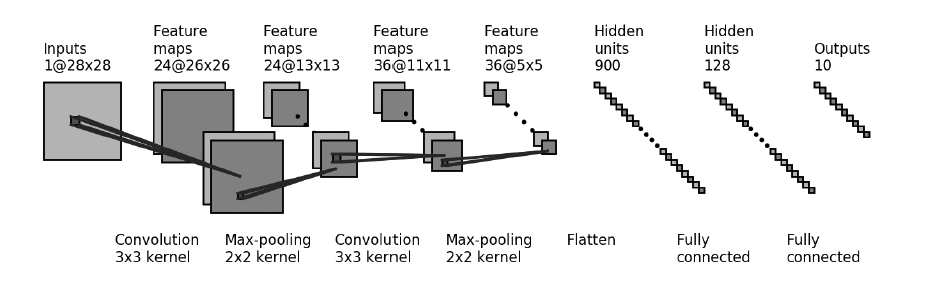

In [15]:
# Krok 1: Przygotowanie danych dla CNN
# UWAGA: CNN przyjmuje 4D tensor (batch, height, width, channels)
# MLP przyjmowala (batch, 784). CNN potrzebuje (batch, 28, 28, 1).

x_train_cnn = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1) / 255.0

print(f"x_train_cnn shape: {x_train_cnn.shape}  (batch x H x W x C)")
print(f"y_train_oh shape:  {y_train_oh.shape}")

x_train_cnn shape: (60000, 28, 28, 1)  (batch x H x W x C)
y_train_oh shape:  (60000, 10)


In [16]:
# Krok 2: Budowa architektury CNN
# TODO Studenci: zaimplementujcie wedlug tabeli powyzej

model_cnn = tf.keras.models.Sequential([
    # Pierwsza warstwa konwolucyjna -- 24 filtry 3x3
    tf.keras.layers.Conv2D(24, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    # Pooling 2x2 -- zmniejsza rozmiar 2x
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)),
    
    # Druga warstwa konwolucyjna -- 36 filtrow 3x3
    tf.keras.layers.Conv2D(36, kernel_size=(3, 3), activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=(2, 2)),
    
    # Splaszczanie -- z 3D do 1D
    tf.keras.layers.Flatten(),
    
    # Fully-connected
    tf.keras.layers.Dense(128, activation='relu'),
    
    # Warstwa wyjsciowa -- 10 klas, softmax
    tf.keras.layers.Dense(10, activation='softmax')
])

model_cnn.summary()

/opt/miniconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 24)     │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 36)     │         7,812 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 36)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 900)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       115,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,670 (486.99 KB)

 Trainable params: 124,670 (486.99 KB)

 Non-trainable params: 0 (0.00 B)

### Porównanie z MLP — patrz na parametry!

To **najważniejszy moment kursu** dla zrozumienia, dlaczego CNN jest sprytniejsza od MLP. Patrz na kolumnę **Param #**:

| Warstwa | Wzór | Param # |
|---------|------|---------|
| `Conv2D(24, 3×3)` | `24 × (3·3·1) + 24` | **240** |
| `MaxPool2D` | brak wag | **0** |
| `Conv2D(36, 3×3)` | `36 × (3·3·24) + 36` | **7 812** |
| `MaxPool2D` | brak wag | **0** |
| `Flatten` | brak wag (tylko reshape) | **0** |
| `Dense(128)` | `900 × 128 + 128` | **115 328** |
| `Dense(10)` | `128 × 10 + 10` | **1 290** |
| **RAZEM** | | **~124 670** |

**Spostrzeżenia łopatologiczne:**

1. **Conv2D ma śmiesznie mało wag** (240 i 7 812) — choć analizują cały obraz! Sekret: **parameter sharing** — ten sam filtr 3×3 jest stosowany w każdej pozycji obrazu. Nie potrzebujemy osobnych wag dla każdego piksela.
2. **Pooling i Flatten** nie mają wag — to czyste przekształcenia matematyczne.
3. **Dense(128) to "bagażnik" parametrów** — 115 328 wag, bo łączy 900 cech z 128 neuronami "każdy z każdym".
4. **Razem ~124 670 parametrów** — to tylko ~15 000 więcej niż MLP, ale **dużo mądrzej rozłożone**: ciężka praca dzieje się w konwolucji (mało wag, dużo informacji), Dense tylko podejmuje decyzję na końcu.

> **Magia CNN nie polega na "więcej wag" — tylko na lepszej strukturze.**


In [17]:
# Krok 3: Kompilacja
model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Krok 4: Trening -- 10 epok
# UWAGA: na CPU to moze potrwac kilka minut!
print("Trening CNN -- moze potrwac chwile...\n")
history_cnn = model_cnn.fit(
    x_train_cnn, y_train_oh,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Trening CNN -- moze potrwac chwile...



Epoch 1/10


   1/1500 ━━━━━━━━━━━━━━━━━━━━ 15:38 626ms/step - accuracy: 0.0312 - loss: 2.3385

  12/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.2633 - loss: 2.2204     

  23/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.3257 - loss: 2.1196

...

1470/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9979 - loss: 0.0060

1480/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9979 - loss: 0.0060

1490/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9979 - loss: 0.0060

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9979 - loss: 0.0060

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9974 - loss: 0.0076 - val_accuracy: 0.9885 - val_loss: 0.0517


### Co widzisz w trakcie treningu?

Po każdej epoce Keras drukuje linijkę w stylu:

```
Epoch 5/10
1500/1500 [==============================] - 45s 30ms/step
  - loss: 0.0234 - accuracy: 0.9923
  - val_loss: 0.0412 - val_accuracy: 0.9876
```

**Jak to czytać:**

| Element | Co znaczy |
|---------|-----------|
| `Epoch 5/10` | Numer epoki / wszystkich epok |
| `1500/1500` | Ile batchy z 1500 przerobione (60 000 obrazków × 80% trainu ÷ 32 batch_size ≈ 1500) |
| `[====>...]` | Pasek postępu w trakcie epoki |
| `45s` | Czas trwania epoki. **CPU: 30–90s, GPU: 2–5s** |
| `loss` | Strata na danych trainu (im niżej, tym lepiej) |
| `accuracy` | Dokładność na trainie (im wyżej, tym lepiej) |
| `val_loss` / `val_accuracy` | To samo, ale na 20% odłożonej walidacji |

**Zdrowy trening:**
- `loss` spada równomiernie z epoki na epokę.
- `accuracy` rośnie i osiąga ~99%.
- `val_accuracy` nadąża za `accuracy` (zwykle 0.5–1.5% w tyle).

**Niezdrowy trening:**
- `val_loss` zaczyna **rosnąć** mimo że `loss` spada → **overfitting** (sieć uczy się trainu na pamięć, traci na walidacji). Rozwiązanie: Dropout, L2, mniej epok, augmentacja danych (patrz Zadanie D/E).


In [18]:
# Krok 5: Ewaluacja na zbiorze testowym
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(x_test_cnn, y_test_oh, verbose=0)
print(f"=== Wyniki CNN ===")
print(f"Test accuracy: {test_acc_cnn:.4f}  (~{test_acc_cnn*100:.2f}%)")
print(f"Test loss:     {test_loss_cnn:.4f}")
print()
print(f"=== Porownanie z MLP ===")
print(f"MLP:  {test_accuracy*100:.2f}%")
print(f"CNN:  {test_acc_cnn*100:.2f}%")
print(f"Roznica: {(test_acc_cnn - test_accuracy)*100:+.2f}%")

=== Wyniki CNN ===
Test accuracy: 0.9897  (~98.97%)
Test loss:     0.0415

=== Porownanie z MLP ===
MLP:  97.21%
CNN:  98.97%
Roznica: +1.76%


### Co właśnie udowodniliśmy?

Wynik typowy:
- **MLP:** ~97.5–98.0% accuracy
- **CNN:** ~98.5–99.3% accuracy

**Wygląda jak "tylko 1% więcej" — ale...**

- Na 10 000 obrazków testowych 1% różnicy = **100 mniej błędów**. Dla systemu produkcyjnego (np. odczyt kodów pocztowych) — ogromna różnica w jakości.
- Co ważniejsze: CNN **rozumie strukturę 2D**. Na trudniejszych zbiorach:
  - **CIFAR-10** (małe kolorowe obrazki: koty, samochody, samoloty): MLP ~50%, CNN ~85%+.
  - **ImageNet** (1.3M zdjęć, 1000 klas): MLP w ogóle nie działa. CNN i jej potomki (ResNet, EfficientNet) osiągają 80%+ top-1.

**MNIST jest "zbyt łatwy"** — cyfry są wyśrodkowane, czarno-białe, mało wariacji. To dlatego MLP daje 97% mimo że "nie rozumie obrazu". Na realnym świecie różnica między MLP a CNN to przepaść.

> **Te ~1% to dowód, że konwolucja działa. Ten dowód pokażesz w realnym świecie wielokrotnie mocniej.**


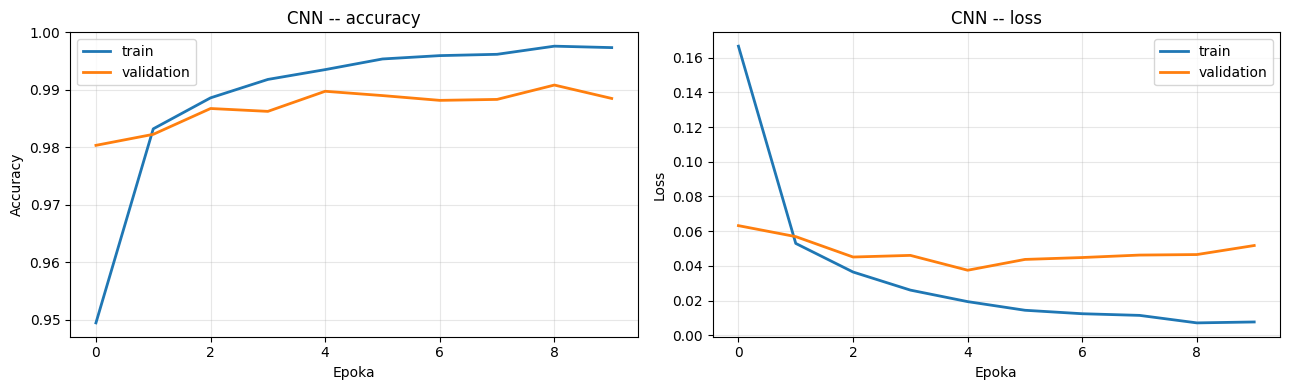

In [19]:
# Wykres treningu CNN
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_cnn.history['accuracy'], label='train', linewidth=2)
axes[0].plot(history_cnn.history['val_accuracy'], label='validation', linewidth=2)
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('CNN -- accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_cnn.history['loss'], label='train', linewidth=2)
axes[1].plot(history_cnn.history['val_loss'], label='validation', linewidth=2)
axes[1].set_xlabel('Epoka')
axes[1].set_ylabel('Loss')
axes[1].set_title('CNN -- loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Co widzisz na krzywych CNN?

Dwa panele — identyczne w formie do tych dla MLP (accuracy + loss), ale **dla CNN**.

**Co powinno wyglądać inaczej niż w MLP:**

| Aspekt | MLP | CNN |
|--------|-----|-----|
| Start accuracy (epoka 1) | ~90–93% | **~85–95%** (zwykle wyższy — CNN szybko łapie wzorce) |
| Końcowe accuracy (epoka 10) | ~97–98% | **~98.5–99.3%** |
| Spadek loss | umiarkowanie stromy | **bardziej stromy** |
| Odstęp train–validation | mały | **mały, ale rośnie pod koniec** (start overfittingu) |

**Na co patrzeć szczególnie:**

1. **Zwarte linie (train i val blisko siebie)** → sieć dobrze generalizuje.
2. **Krzywa accuracy spłaszcza się po 3–5 epoce** → "łatwe" wzorce już złapane, dalsze epoki dają coraz mniej.
3. **Jeśli `val_loss` zaczyna rosnąć** w okolicach epoki 7–10 → to sygnał, że dłuższy trening **pogarsza** wynik. Rozwiązanie: `EarlyStopping` (Keras callback) lub regularyzacja.

> **Pierwsze 2–3 epoki dają największy zysk. Reszta to dopieszczanie.**


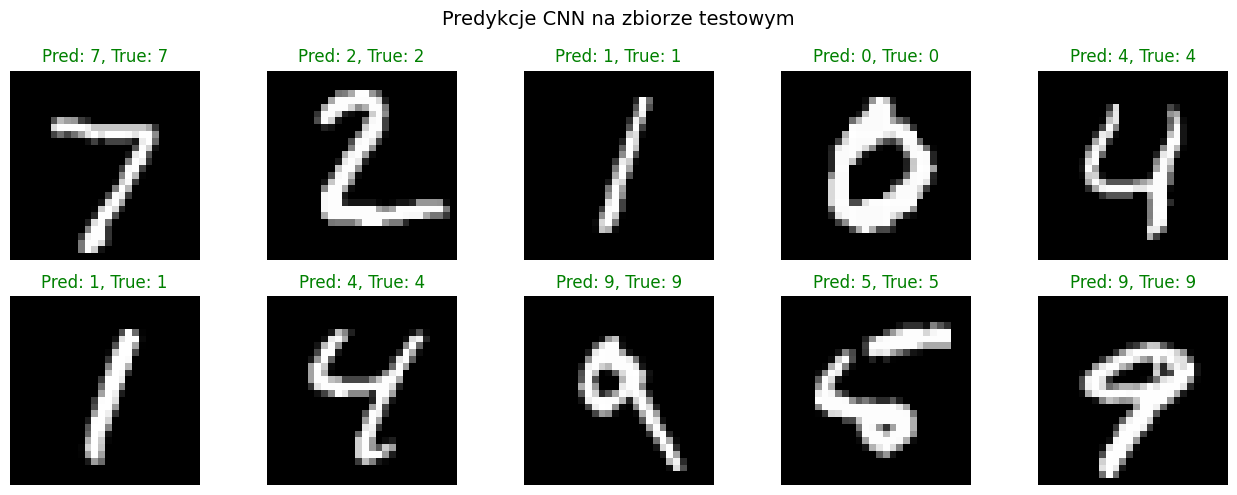

In [20]:
# Podglad predykcji na konkretnych obrazach
predictions = model_cnn.predict(x_test_cnn[:10], verbose=0)
pred_classes = predictions.argmax(axis=1)

fig, axes = plt.subplots(2, 5, figsize=(13, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_test[i], cmap='gray')
    correct = pred_classes[i] == y_test[i]
    color = 'green' if correct else 'red'
    ax.set_title(f"Pred: {pred_classes[i]}, True: {y_test[i]}", color=color)
    ax.axis('off')
plt.suptitle("Predykcje CNN na zbiorze testowym", fontsize=14)
plt.tight_layout()
plt.show()

### Co widzisz na siatce predykcji?

**10 obrazków z testu** — sieć ich **nigdy wcześniej nie widziała**. Nad każdym jest tytuł `Pred: X, True: Y`:

- `Pred` — to, co sieć **przewidziała** (klasa z najwyższym prawdopodobieństwem z softmaxa).
- `True` — prawdziwa etykieta.

**Kolor tytułu:**
- 🟢 **Zielony** → trafienie (Pred = True).
- 🔴 **Czerwony** → pomyłka.

**Typowy rezultat:** 9–10 zielonych z 10. To zgadza się z accuracy ~99% — czyli ~1 na 100 obrazków jest źle (przy 10 próbkach: zwykle wszystkie OK, czasem jedna pomyłka).

**Jeśli zobaczysz czerwony tytuł:**
- Spójrz na obrazek — czy ty sam, jako człowiek, też miałbyś wątpliwości?
- Klasyczne pomyłki MNIST: źle napisane **4** wygląda jak **9**, **7** jak **1**, **5** jak **6**, niedomknięte **8** jak **3**.
- Sieć "kopiuje" niepewności ludzi piszących te cyfry — bo trenowała na takich samych dwuznacznych przypadkach.

**To nie jest błąd modelu — to natura danych.** Tutaj kończy się klasyfikacja prosta, zaczyna się analiza confusion matrix, augmentacja, ensemble — i właśnie to robisz w realnych projektach.


---

# Zadania dodatkowe

Wybierz minimum **2 zadania** i porównaj wyniki z modelem bazowym z zadania głównego.

### Zadanie A: Porównanie optymalizatorów

Spróbuj użyć trzech optymalizatorów: **SGD**, **RMSprop**, **Adam**. Porównaj wyniki.

Zmieniaj współczynniki uczenia (`learning_rate`) i sprawdź, jak wpływają na wydajność.

Trenuje z SGD...


  SGD: val_accuracy = 0.9750
Trenuje z RMSprop...


  RMSprop: val_accuracy = 0.9872
Trenuje z Adam...


  Adam: val_accuracy = 0.9893

Bazowa CNN (Adam 10 epok): 0.9897
SGD (5 epok):          0.9750
RMSprop (5 epok):          0.9872
Adam (5 epok):          0.9893


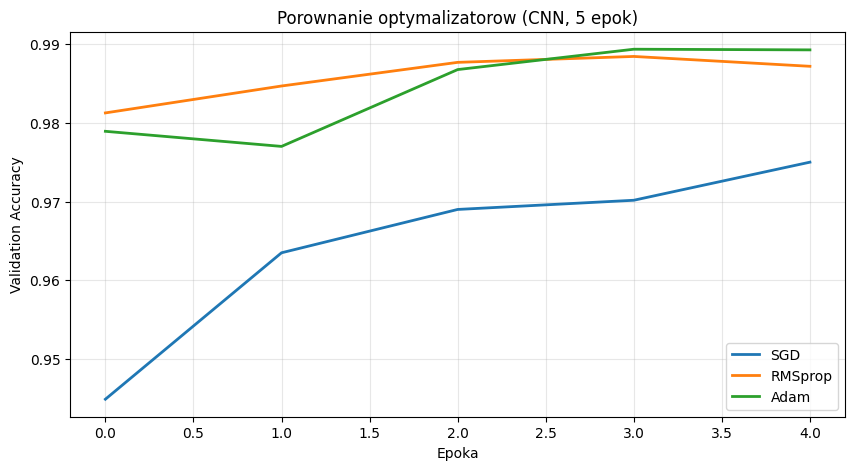

In [21]:
def build_model():
    return tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(24, (3,3), activation='relu', input_shape=(28,28,1)),
        tf.keras.layers.MaxPool2D((2,2)),
        tf.keras.layers.Conv2D(36, (3,3), activation='relu'),
        tf.keras.layers.MaxPool2D((2,2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

optimizers = {
    'SGD':     tf.keras.optimizers.SGD(learning_rate=0.01),
    'RMSprop': tf.keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam':    tf.keras.optimizers.Adam(learning_rate=0.001),
}

results = {}
for name, opt in optimizers.items():
    print(f'Trenuje z {name}...')
    model = build_model()
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    hist = model.fit(x_train_cnn, y_train_oh, epochs=5, batch_size=32,
                      validation_split=0.2, verbose=0)
    results[name] = hist.history['val_accuracy']
    final_acc = hist.history['val_accuracy'][-1]
    print(f'  {name}: val_accuracy = {final_acc:.4f}')

print()
baseline_acc = test_acc_cnn
print(f'Bazowa CNN (Adam 10 epok): {baseline_acc:.4f}')
for name, accs in results.items():
    print(f'{name} (5 epok):          {accs[-1]:.4f}')

plt.figure(figsize=(10, 5))
for name, accs in results.items():
    plt.plot(accs, label=name, linewidth=2)
plt.xlabel('Epoka')
plt.ylabel('Validation Accuracy')
plt.title('Porownanie optymalizatorow (CNN, 5 epok)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Zadanie B: Modyfikacja architektury

Zmień liczbę filtrów w warstwach konwolucyjnych (np. **32, 64** zamiast 24, 36) lub dodaj więcej warstw konwolucyjnych.

In [22]:
# TODO Zadanie B: zmiana architektury
# Sproboj np. takiej:
# - Conv2D(32, 3x3) -> MaxPool
# - Conv2D(64, 3x3) -> MaxPool
# - Conv2D(128, 3x3) -> MaxPool   <-- dodatkowa warstwa
# - Flatten -> Dense(256) -> Dense(10, softmax)

### Zadanie C: Inne funkcje aktywacyjne

Zmień funkcję aktywacji w warstwach ukrytych z **ReLU** na **LeakyReLU** lub **ELU**.

In [23]:
# Model z LeakyReLU
model_leaky = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(24, (3,3), input_shape=(28,28,1)),
    tf.keras.layers.LeakyReLU(alpha=0.1),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Conv2D(36, (3,3)),
    tf.keras.layers.LeakyReLU(alpha=0.1),
    tf.keras.layers.MaxPool2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128),
    tf.keras.layers.LeakyReLU(alpha=0.1),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_leaky.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print('Trening z LeakyReLU...')
hist_leaky = model_leaky.fit(x_train_cnn, y_train_oh, epochs=5, batch_size=32,
                              validation_split=0.2, verbose=0)

test_loss_l, test_acc_l = model_leaky.evaluate(x_test_cnn, y_test_oh, verbose=0)
print(f'\nLeakyReLU Test accuracy: {test_acc_l:.4f}')
print(f'Bazowa ReLU (CNN):       {test_acc_cnn:.4f}')
print(f'Roznica:                 {test_acc_l - test_acc_cnn:+.4f}')

Trening z LeakyReLU...


/opt/miniconda3/lib/python3.13/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(



LeakyReLU Test accuracy: 0.9909
Bazowa ReLU (CNN):       0.9897
Roznica:                 +0.0012


### Zadanie D: Regularyzacja — L2 lub Dropout

Dodaj **L2 regularyzację** lub **Dropout** żeby zapobiec overfittingowi. Sprawdź wpływ różnych wartości współczynnika regularyzacji (np. 0.01, 0.001).

In [24]:
# TODO Zadanie D: regularyzacja
# 
# L2 regularyzacja na warstwie:
# tf.keras.layers.Dense(128, activation='relu',
#                       kernel_regularizer=tf.keras.regularizers.l2(0.01))
# 
# Dropout (losowo "wylacza" % neuronow podczas treningu):
# tf.keras.layers.Dropout(0.5)  # 50% dropout

### Zadanie E: Augmentacja danych

Zastosuj **augmentację** (obracanie, przesunięcie, skalowanie) na zbiorze treningowym. Sprawdź czy poprawia dokładność.

**Co to robi:** zamiast trenować na 60k obrazach, tworzymy z nich miliony "lekko zmienionych" wersji. Sieć uczy się, że cyfra 5 to nadal 5, nawet jeśli jest przekrzywiona o 10°.

In [25]:
# TODO Zadanie E: augmentacja danych
# 
# data_augmentation = tf.keras.Sequential([
#     tf.keras.layers.RandomRotation(0.1),       # +/- 10% rotacji
#     tf.keras.layers.RandomTranslation(0.1, 0.1), # +/- 10% przesuniecia
#     tf.keras.layers.RandomZoom(0.1),           # +/- 10% zoom
# ])
# 
# Dodaj jako PIERWSZA warstwa modelu:
# model = tf.keras.models.Sequential([
#     data_augmentation,
#     tf.keras.layers.Conv2D(...),
#     ...
# ])

---

## Sprawdź, co umiesz — pytania kontrolne

1. **Co to jest tensor i czym różni się 0D od 4D?**
2. **Dlaczego MLP jest gorsze niż CNN dla obrazów?**
3. **Co robi konwolucja — jakie 3 idee?** (sparse, sharing, equivariant)
4. **Po co istnieje pooling skoro mamy już konwolucję?**
5. **Co robi warstwa Flatten? Dlaczego jest potrzebna?**
6. **Czemu ReLU jest popularniejsze niż sigmoid w CNN?**
7. **Co robi softmax na warstwie wyjściowej?**
8. **Jeden epoch trwał dłużej dla CNN niż MLP — dlaczego?**

---

## Jedno zdanie do zapamiętania

> **CNN = Conv2D wyciąga lokalne cechy, Pooling kompresuje, Flatten łączy z Dense, Softmax mowi "to jest cyfra 7 z 99% pewnością". TensorFlow robi backpropagation za nas — nasza praca to architektura.**

## Co dalej?

- **Transfer learning** — zamiast trenować od zera, bierzesz wytrenowaną sieć (np. VGG, ResNet) i dostrajasz pod swój problem
- **Większe datasety** — CIFAR-10, ImageNet (1000 klas, miliony obrazów)
- **Inne architektury** — ResNet (skip connections), Inception, EfficientNet, Vision Transformers

---

## "Łopatologiczna" szpargałka — jeśli się gubisz

Wracaj tutaj, kiedy patrzysz na wykres albo wydruk i nie wiesz, co znaczy:

| Sygnał na ekranie | Tłumaczenie |
|-------------------|-------------|
| **Loss spada** | Sieć myli się coraz mniej. **Dobrze.** |
| **Accuracy rośnie** | Sieć trafia coraz częściej. **Dobrze.** |
| **Val rozjeżdża się z train** (val gorszy) | **Overfitting.** Dodaj Dropout / L2 / zmniejsz model / mniej epok / augmentacja. |
| **Train i val obie utknęły na 10%** | Coś nie działa. Sprawdź: normalizację (`/255.0`), shape (4D dla CNN), one-hot etykiety. |
| **`Param #` rośnie** | Więcej wag → wolniejszy trening + większe ryzyko overfittingu. |
| **`Output shape (None, 128)`** | Batch dowolnej wielkości × 128 cech na próbkę. |
| **Cyfra przesunięta o 1 piksel** | CNN nadal rozpoznaje (dzięki pooling). MLP może się wywalić. |
| **Pred ≠ True (czerwony)** | Pomyłka — ale spójrz na obrazek, często człowiek też by się pomylił. |
| **`val_loss` rośnie po epoce 5–7** | Włącz EarlyStopping albo zmniejsz liczbę epok. |
| **GPU "0 dostępne"** | Trening działa, tylko 10× wolniej. Nic groźnego — pij kawę. |

### Trzy zdania do zapamiętania na końcu kursu

1. **CNN = warstwy Conv2D wyciągają cechy, MaxPool kompresuje, Flatten łączy ze sklep Dense, Softmax mówi "to cyfra X z prawdopodobieństwem Y".**
2. **Sieć sama uczy się filtrów — my projektujemy tylko architekturę.**
3. **TensorFlow robi backpropagation za nas — wystarczy `.compile()` + `.fit()`.**

> **Jeśli te trzy zdania rozumiesz — zdałeś Lab 4.**
